# Directed Evolution loop — V1

First simple test of `sequence_classesV1.py` (`Protocol`, `Lambda`) and `analysisV1.py`
(the 8 plotting/analysis functions), on a small toy library.

Pipeline for one round of `Protocol.loop_DE()`:

$$
\lambda_0 \xrightarrow{\text{NGS}} \lambda_0' \qquad
\lambda_0 \xrightarrow{\text{sampling}} \lambda_1 \xrightarrow{\text{produce\_capsids}} \lambda_2 \xrightarrow{\text{NGS}} \lambda_2' \qquad
\lambda_2 \xrightarrow{\text{selectivty}} \lambda_3 \xrightarrow{\text{NGS}} \lambda_3' \qquad
\lambda_3 \xrightarrow{\text{bacterial\_amplification}} \lambda_4
$$

`lambda0/1/2/3/4` = true pools (biological chain). `lambda0p/2p/3p` = NGS read-count
snapshots (side channel, Negative Binomial, never fed back into the chain).


## 0. Protocol parameters

Fixed constants from `sequence_classesV1.py`, used as defaults throughout `Protocol` unless overridden at construction time.

In [1]:
import sequence_classesV1
print(sequence_classesV1.__file__)
print(sequence_classesV1.message)

/Users/merlincc/Library/Mobile Documents/com~apple~CloudDocs/IDV AAV/Directed-Evolution-loop/Modelization_V1/sequence_classesV1.py
file 1.3


In [2]:
import analysisV1
print(analysisV1.__file__)
print(analysisV1.message)

/Users/merlincc/Library/Mobile Documents/com~apple~CloudDocs/IDV AAV/Directed-Evolution-loop/Modelization_V1/analysisV1.py
file analysis 1.1


In [3]:
import pandas as pd
from sequence_classesV1 import rho, alpha, epsilon, T_sel, T_viab, M, K_MM, K_MM_amp, N_pcr, D, N1, phi

params = pd.DataFrame([
    ("rho",     rho,     "HEK cells transfected per plasmid"),
    ("alpha",   alpha,   "capsid yield per transfected cell"),
    ("epsilon", epsilon, "per-cell production noise amplitude"),
    ("T_sel",   T_sel,   "selectivity temperature"),
    ("T_viab",  T_viab,  "viability temperature (larger = more uniform production)"),
    ("M",       M,       "number of PCR amplification cycles"),
    ("K_MM",    K_MM,    "Michaelis-Menten saturation constant for PCR"),
    ("K_MM_amp",K_MM_amp,"same as before"),
    ("N_pcr",   N_pcr,   "pipetting depth before PCR amplification (NGS pipeline)"),
    ("D",       D,       "sequencing depth (reads per NGS readout)"),
    ("N1",      N1,      "number of plasmids sampled for transfection"),
    ("phi",     phi,     "NB dispersion for sequencing reads (smaller phi = closer to Poisson)"),
], columns=["Parameter", "Value", "Description"])

params

,Parameter,Value,Description
0,rho,1.000000e-03,HEK cells transfected per plasmid
1,alpha,4.000000e+03,capsid yield per transfected cell
2,epsilon,1.000000e-02,per-cell production noise amplitude
3,T_sel,5.000000e-01,selectivity temperature
4,T_viab,5.000000e-01,viability temperature (larger = more uniform p...
5,M,4.000000e+01,number of PCR amplification cycles
6,K_MM,1.000000e+06,Michaelis-Menten saturation constant for PCR
7,K_MM_amp,1.000000e+08,same as before
8,N_pcr,1.000000e+06,pipetting depth before PCR amplification (NGS ...
9,D,1.000000e+08,sequencing depth (reads per NGS readout)


## 1. Imports

In [4]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from sequence_classesV1 import *
from analysisV1 import *

## 2. Toy library and ground-truth (Teacher) Potts model

Small library so the whole notebook runs in seconds. `F_viab`/`F_sel` are dense
random profile matrices; `J_viab`/`J_sel` are *sparse* (only a handful of nonzero
pairwise couplings each) — a dense random `J` blows up `exp(score/T)` in
`produce_capsids` since it sums scores over every transfected cell.

In [5]:
key = jax.random.key(0)
key, k_seq, k_Fv, k_Fs, k_Jv, k_Js = jax.random.split(key, 6)

num_sequences   = 800000
L               = 7     # sequence length
A               = 20    # amino-acid alphabet size

sequences = jax.random.randint(k_seq, shape=(num_sequences, L), minval=0, maxval=A)

F_viab, F_sel, J_viab, J_sel  = initialize_random_weights(key=key)

print(f"Library: {num_sequences} sequences of length {L}")
print(f"F_viab shape: {F_viab.shape}, J_viab nonzero entries: {int(jnp.sum(J_viab != 0))}")

Library: 800000 sequences of length 7
F_viab shape: (20, 7), J_viab nonzero entries: 16800


Sanity check with `plot_teacher_weights` (function 1 from `analysisV1.py`):

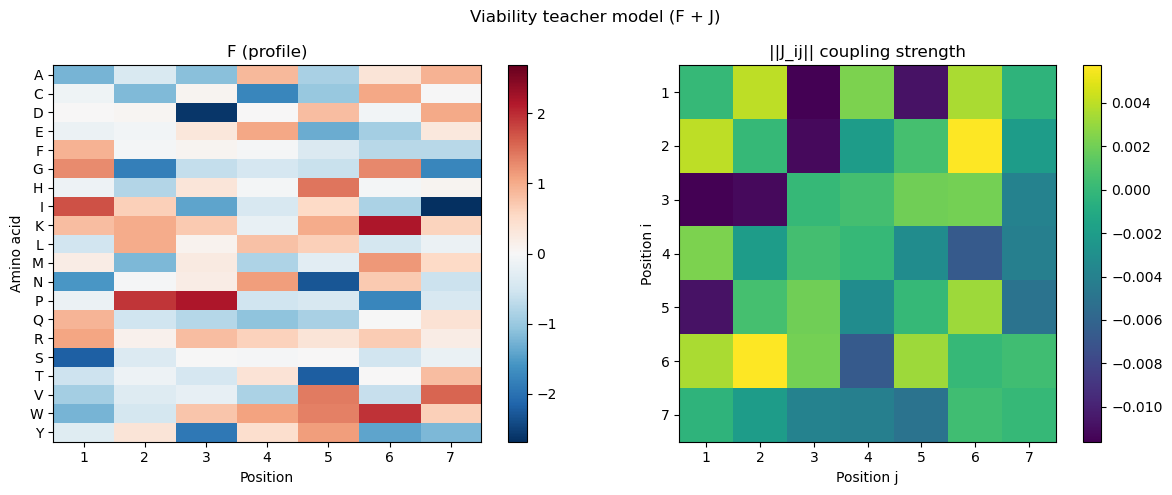

In [6]:
_ = plot_teacher_weights(F_viab, J_viab, title="Viability teacher model (F + J)")
plt.show()

## 3. Build the `Protocol`

`Protocol` wraps the whole simulation: `sequence` (identity, `(d0, 7)`, constant) and
`lambda0..lambda4` / `lambda0p,2p,3p` (abundance pools, all `(d0,)`, evolve each round).

In [7]:
protocol = ProtocolV2(
    N0=100_000_000, N1=N1, sequences=sequences, D=D,
    F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
    noise_viab=0.1, noise_sel=0.1,
)

print("protocol.sequence shape:", protocol.sequence.shape, "  (identity, never changes)")
print("protocol.model     :", protocol.model)
print()
print("Lambda shapes right after construction (should all be (d0,) = (%d,)):" % protocol.d0)
for name in ["lambda0", "lambda0p", "lambda1", "lambda2", "lambda2p", "lambda3", "lambda3p", "lambda4"]:
    print(f"  {name:10s} : {getattr(protocol, name).shape}")

protocol.sequence shape: (800000, 7)   (identity, never changes)
protocol.model     : Potts

Lambda shapes right after construction (should all be (d0,) = (800000,)):
  lambda0    : (800000,)
  lambda0p   : (800000,)
  lambda1    : (800000,)
  lambda2    : (800000,)
  lambda2p   : (800000,)
  lambda3    : (800000,)
  lambda3p   : (800000,)
  lambda4    : (800000,)


Initial library, colored by viability/selectivity score (function 2):

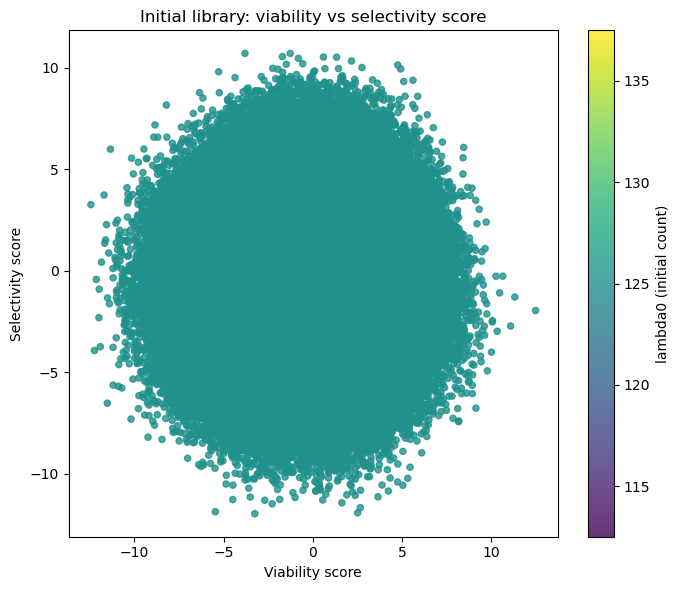

In [8]:
_ = plot_initial_library_scores(protocol)
plt.show()

## 4. Run one round of `loop_DE()`

In [9]:
bio_row, ngs_row = protocol.loop_DE()
lambda0, lambda1, lambda2, lambda3, lambda4 = bio_row
lambda0p, lambda2p, lambda3p = ngs_row

print("After loop_DE():")
for label, arr in [("lambda0", lambda0), ("lambda1", lambda1), ("lambda2", lambda2),
                    ("lambda3", lambda3), ("lambda4", lambda4),
                    ("lambda0p", lambda0p), ("lambda2p", lambda2p), ("lambda3p", lambda3p)]:
    arr = np.array(arr)
    print(f"  {label:10s} total={arr.sum():>14,.0f}  non-zero={(arr > 0).sum():>4d} / {protocol.d0}")

After loop_DE():
  lambda0    total=   100,000,000  non-zero=800000 / 800000
  lambda1    total=     9,998,129  non-zero=799997 / 800000
  lambda2    total=123,521,843,200  non-zero=9145 / 800000
  lambda3    total=43,054,538,752  non-zero=7981 / 800000
  lambda4    total=   100,000,712  non-zero=4732 / 800000
  lambda0p   total=   100,015,551  non-zero=569801 / 800000
  lambda2p   total=    96,869,545  non-zero=2464 / 800000
  lambda3p   total=    94,104,246  non-zero=2037 / 800000


Counts through viability + selectivity (function 3):

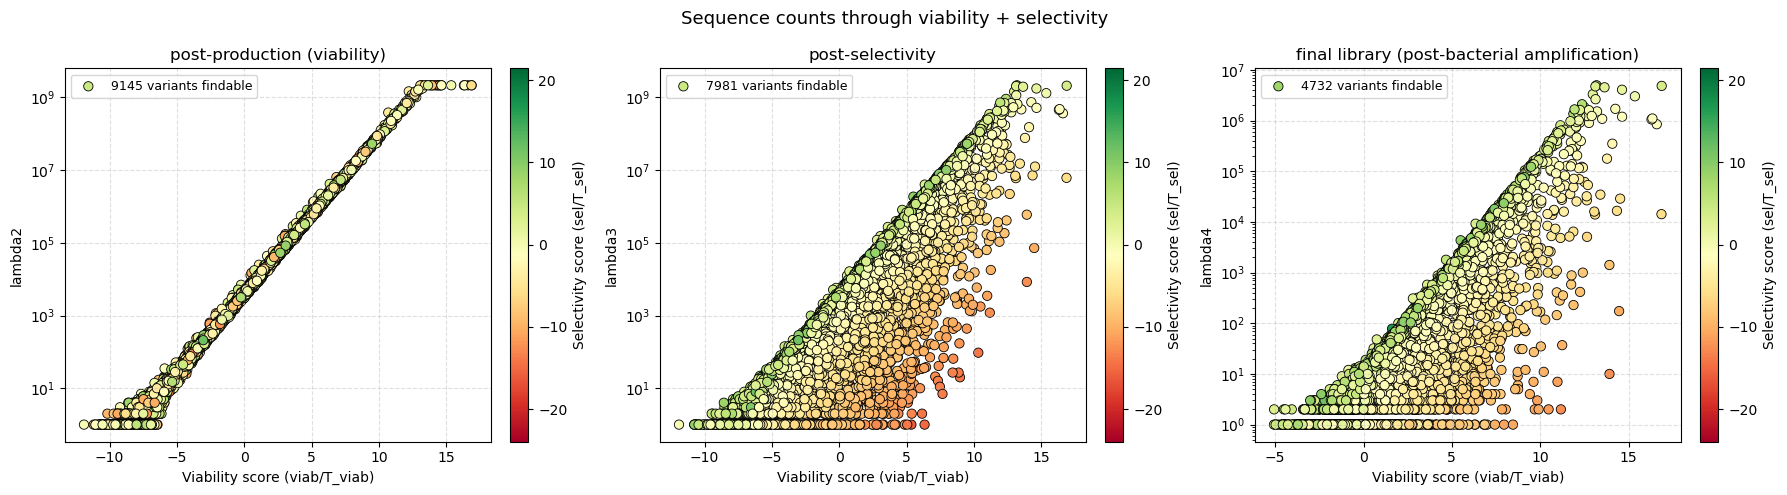

In [10]:
_ = plot_counts_after_selection(protocol)
plt.show()

All 8 lambdas of that same round on one plot (function 8):

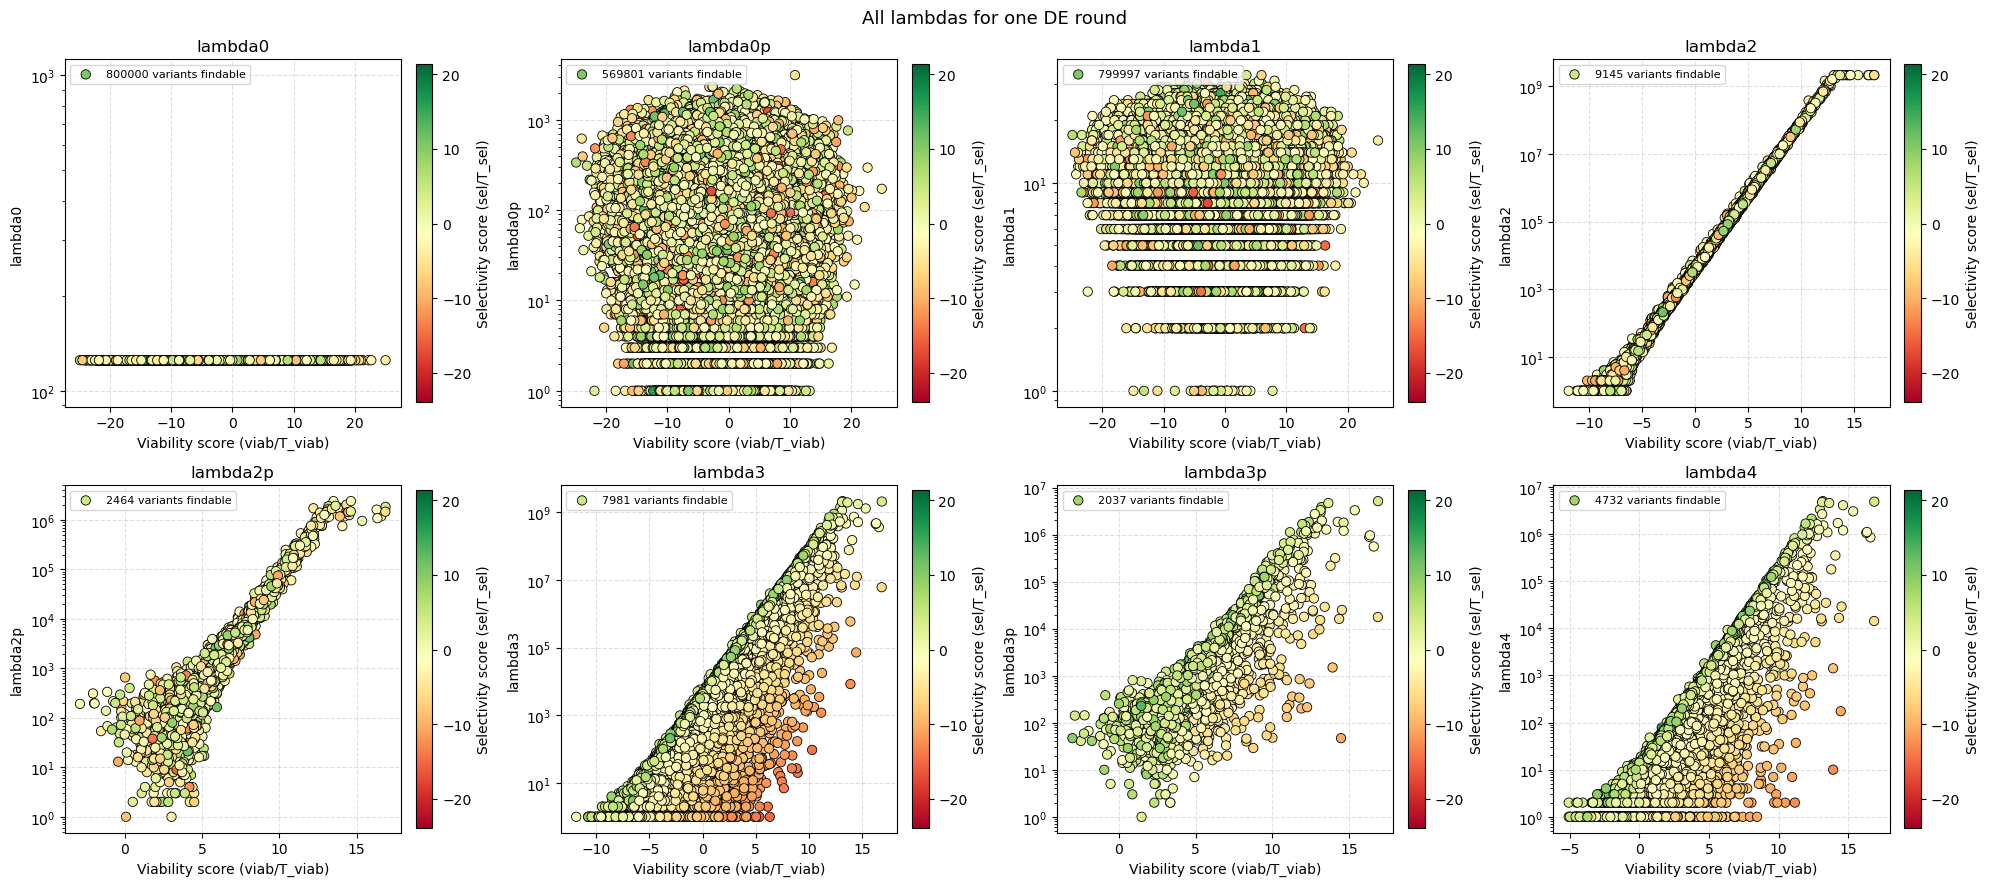

In [11]:
_ = plot_loop_lambdas(protocol, run_loop=False)  # reuse the round we just ran
plt.show()

## 5. Run several rounds with `N_loop_DE` and track library evolution

Directed evolution rounds:   0%|          | 0/5 [00:00<?, ?it/s]

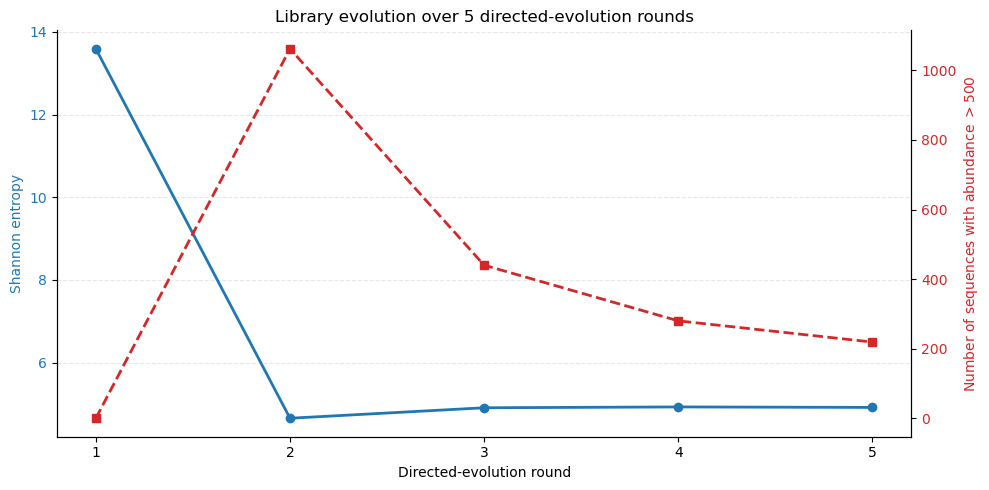

N_loop_DE returned 5 rounds


In [12]:
protocol_multi = ProtocolV2(
    N0=100_000_000, N1=10_000_000, sequences=sequences, 
    D=D, F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, 
    J_sel=J_sel, noise_viab=0.01, noise_sel=0.01,
)

fig, rounds = plot_library_evolution(protocol_multi, N=5, threshold=500)
plt.show()

print(f"N_loop_DE returned {len(rounds)} rounds")

Top-10% recovery of combined score vs final library abundance after N rounds (function 9 from `analysisV1.py`):

In [ ]:
protocol_topk = ProtocolV2(
    N0=100_000_000, N1=10_000_000, sequences=sequences,
    D=D, F_viab=F_viab, J_viab=J_viab, F_sel=F_sel,
    J_sel=J_sel, noise_viab=0.01, noise_sel=0.01,
)

fig, rounds = plot_topk_recovery_final_library(protocol_topk, N=5, k_frac=0.10)
plt.show()

## Summary

Every function in `sequence_classesV1.py` (`Protocol.compute_score`, `NGS`, `sampling`,
`produce_capsids`, `selectivty`, `bacterial_amplification`, `loop_DE`, `N_loop_DE`) and
every one of the 8 plotting functions in `analysisV1.py` ran successfully on this toy
library. Swap in a real library (`sequences`) and real teacher weights to scale up.